In [197]:
import pandas as pd
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

In [198]:
df = pd.read_csv('TempNY.csv')
df = df.drop('Unnamed: 2', axis =1)
df.index = df['Year']
df = df.drop('Year', axis=1)
df

,Average
Year,
1870,53.60
1871,51.13
1872,50.98
1873,50.98
1874,51.34
...,...
2016,57.18
2017,56.22
2018,55.88


In [199]:
len_train = int(len(df)*0.9)
len_train

135

In [200]:
len_test = int(len(df)*0.1)
len_test

15

In [201]:
# Definicion en grupos de prueba y entrenamiento
train = df[0:len_train]
test = df[len_train:]

In [202]:
lista = pd.DataFrame(test.index)
lista2 = [2021, 2022, 2023, 2024, 2025]
lista2 = pd.DataFrame(lista2, columns = ['Year'])

In [203]:
fechas = pd.concat([lista, lista2], ignore_index=True)
fechas = fechas.reset_index()
fechas.drop(columns=['index'], inplace=True)

<Axes: xlabel='Year'>

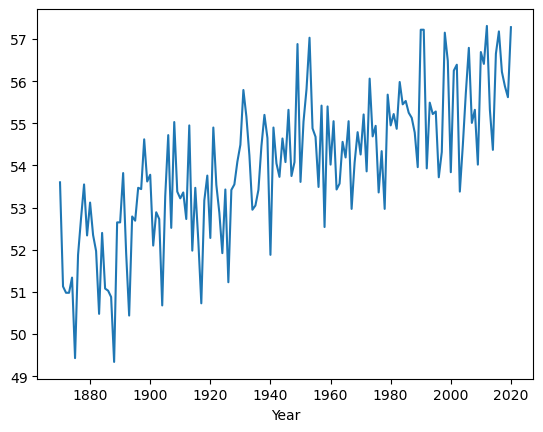

In [204]:
df['Average'].plot()

In [205]:
# Realizacion de la prueba Dickey-Fuller
# H0: La serie es NO ESTACIONARIA
# Ha: La serie es ESTACIONARIA

from statsmodels.tsa.stattools import adfuller
result = adfuller(train)
print('El valor p de la prueba de Dickey-Fuller es: ', result[1])

El valor p de la prueba de Dickey-Fuller es:  0.42201206191180785


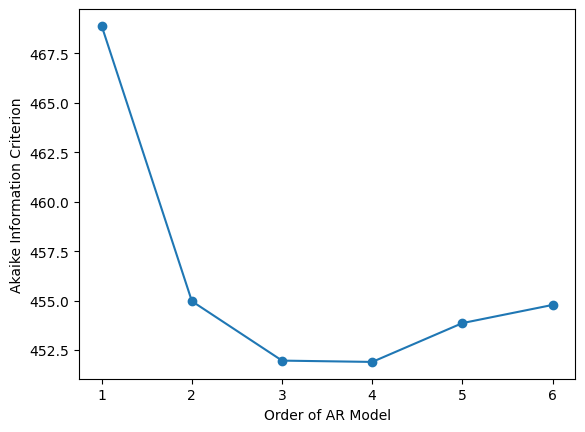

In [227]:
# Determinacion del valor adecuado de p para AR(p) a partir del criterio de informacion Akaike
# Fit the data to an AR(p) for p = 0, ...., 6, and save the AIC
AIC = np.zeros(7)
for p in range(7):
    mod = ARIMA(train, order=(p,0,0))
    res = mod.fit()
# Save AIC for AR(p)
    AIC[p] = res.aic

# Plot the AIC as a function of p
plt.plot(range(1,7), AIC[1:7], marker='o')
plt.xlabel('Order of AR Model')
plt.ylabel('Akaike Information Criterion')
plt.show()

In [226]:
# Aplicar primeras diferencias 
df_diff = df
df_diff['temp_change'] = df['Average'].diff()
df_diff = df_diff.dropna()
df_diff

,Average,temp_change
Year,,
1871,51.13,-2.47
1872,50.98,-0.15
1873,50.98,0.00
1874,51.34,0.36
1875,49.43,-1.91
...,...,...
2016,57.18,0.53
2017,56.22,-0.96
2018,55.88,-0.34


In [208]:
# Aplicacion de la prueba Dickey-Fuller sobre las diferencias
result2 = adfuller(df_diff['temp_change'])
print('El valor p de la prueba de Dickey-Fuller es: ', result2[1])

El valor p de la prueba de Dickey-Fuller es:  8.361907414786182e-14


<Axes: xlabel='Year'>

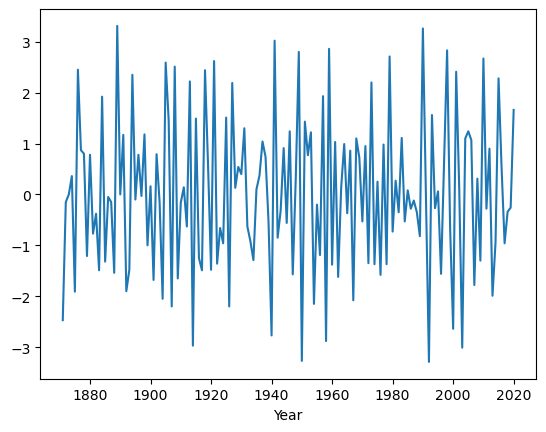

In [209]:
df_diff['temp_change'].plot()

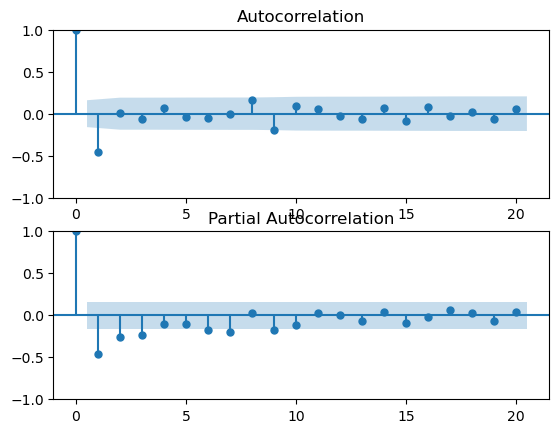

In [210]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2,1)

# Graficacion de la funcion de autocorrelacion ACF
plot_acf(df_diff['temp_change'], lags=20, ax=axes[0], alpha=0.05)

# Graficacion de la funcion de autocorrelacion parcial PACF
plot_pacf(df_diff['temp_change'], lags=20, ax=axes[1], alpha=0.05)

plt.show()

In [211]:
# Importacion del modulo para estimar un modelo ARIMA
from statsmodels.tsa.arima.model import ARIMA 

# Ajustar los datos a un modelo AR(1) e imprimir su AIC:
mod_ar1 = ARIMA(train, order=(1,0,0))
res_ar1 = mod_ar1.fit()
print('El AIC para AR(1) es: ', res_ar1.aic)

El AIC para AR(1) es:  468.89371395861826


In [212]:
# Ajustar los datos a un modelo AR(2) e imprimir su AIC:
mod_ar2 = ARIMA(train, order=(2,0,0))
res_ar2 = mod_ar2.fit()
print('El AIC para AR(2) es: ', res_ar2.aic)

El AIC para AR(2) es:  454.9691797860585


In [233]:
# Ajustar los datos a un modelo AR(3) e imprimir su AIC:
mod_ar3 = ARIMA(train, order=(3,0,0))
res_ar3 = mod_ar3.fit()
print('El AIC para AR(3) es: ', res_ar3.aic)

El AIC para AR(3) es:  451.9638221739301


In [234]:
# Ajustar los datos a un modelo AR(4) e imprimir su AIC:
mod_ar4 = ARIMA(train, order=(4,0,0))
res_ar4 = mod_ar4.fit()
print('El AIC para AR(4) es: ', res_ar4.aic)

El AIC para AR(4) es:  451.89776674963446


In [213]:
# Ajustar los datos a un modelo ARMA(1,1) e imprimir su AIC:
mod_arma11 = ARIMA(train, order=(1,0,1))
res_arma11 = mod_arma11.fit()
print('El AIC para ARMA(1,1) es: ', res_arma11.aic)

El AIC para ARMA(1,1) es:  440.84822442901157


In [231]:
# Ajustar los datos a un modelo ARMA(3,1) e imprimir su AIC:
mod_arma31 = ARIMA(train, order=(3,0,1))
res_arma31 = mod_arma31.fit()
print('El AIC para ARMA(3,1) es: ', res_arma31.aic)

El AIC para ARMA(3,1) es:  444.05511433047445


In [236]:
# Ajustar los datos a un modelo ARMA(4,4) e imprimir su AIC:
mod_arma44 = ARIMA(train, order=(4,0,4))
res_arma44 = mod_arma44.fit()
print('El AIC para ARMA(4,4) es: ', res_arma44.aic)

El AIC para ARMA(4,4) es:  441.59631612843975


In [214]:
# Importacion del modulo ARIMA de statsmodels
from statsmodels.graphics.tsaplots import plot_predict

# Pronostico de temperaturas usando un modelo ARIMA(1,1,1)
mod = ARIMA(train, order=(1,1,1))
res = mod.fit()

print(res.summary())

                               SARIMAX Results                                
Dep. Variable:                Average   No. Observations:                  135
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -214.615
Date:                Sun, 05 Apr 2026   AIC                            435.230
Time:                        19:05:27   BIC                            443.924
Sample:                             0   HQIC                           438.763
                                - 135                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0652      0.116      0.561      0.575      -0.162       0.293
ma.L1         -0.8693      0.058    -14.905      0.000      -0.984      -0.755
sigma2         1.4271      0.211      6.771      0.0

In [215]:
# pronostico puntual para los proximos 5 anos
predicciones = res.forecast(len(test) + 5)
predicciones

135    55.063945
136    55.102007
137    55.104488
138    55.104650
139    55.104660
140    55.104661
141    55.104661
142    55.104661
143    55.104661
144    55.104661
145    55.104661
146    55.104661
147    55.104661
148    55.104661
149    55.104661
150    55.104661
151    55.104661
152    55.104661
153    55.104661
154    55.104661
155    55.104661
Name: predicted_mean, dtype: float64

In [216]:
predicciones = pd.DataFrame(predicciones)
predicciones = predicciones.reset_index()
predicciones.drop(columns=['index'], inplace=True)

In [217]:
frames = [fechas, predicciones]
result = pd.concat(frames, axis=1, join='inner')
result.columns = ['Year', 'Prediciones']

In [218]:
result.index = result['Year']
result.drop(columns=['Year'], inplace=True)
result

,Prediciones
Year,
2005,55.063945
2006,55.102007
2007,55.104488
2008,55.104650
2009,55.104660
2010,55.104661
2011,55.104661
2012,55.104661
2013,55.104661


In [219]:
# Pronostico por intervalo de los proximos 5 anos
conf = res.get_forecast(len(test) + 5).conf_int(alpha=0.05)
conf

,lower Average,upper Average
135,52.722542,57.405348
136,52.716104,57.487910
137,52.695051,57.513925
138,52.672998,57.536302
139,52.651065,57.558256
140,52.629320,57.580002
141,52.607765,57.601557
142,52.586394,57.622928
143,52.565203,57.644119
144,52.544188,57.665135


In [220]:
conf = conf.reset_index()
conf.drop(columns=['index'], inplace=True)

In [221]:
frames = [fechas, conf]
intervalos = pd.concat(frames, axis=1, join='inner')

In [222]:
intervalos.index =intervalos['Year']
intervalos.drop(columns=['Year'], inplace=True)
intervalos

,lower Average,upper Average
Year,,
2005,52.722542,57.405348
2006,52.716104,57.487910
2007,52.695051,57.513925
2008,52.672998,57.536302
2009,52.651065,57.558256
2010,52.629320,57.580002
2011,52.607765,57.601557
2012,52.586394,57.622928
2013,52.565203,57.644119


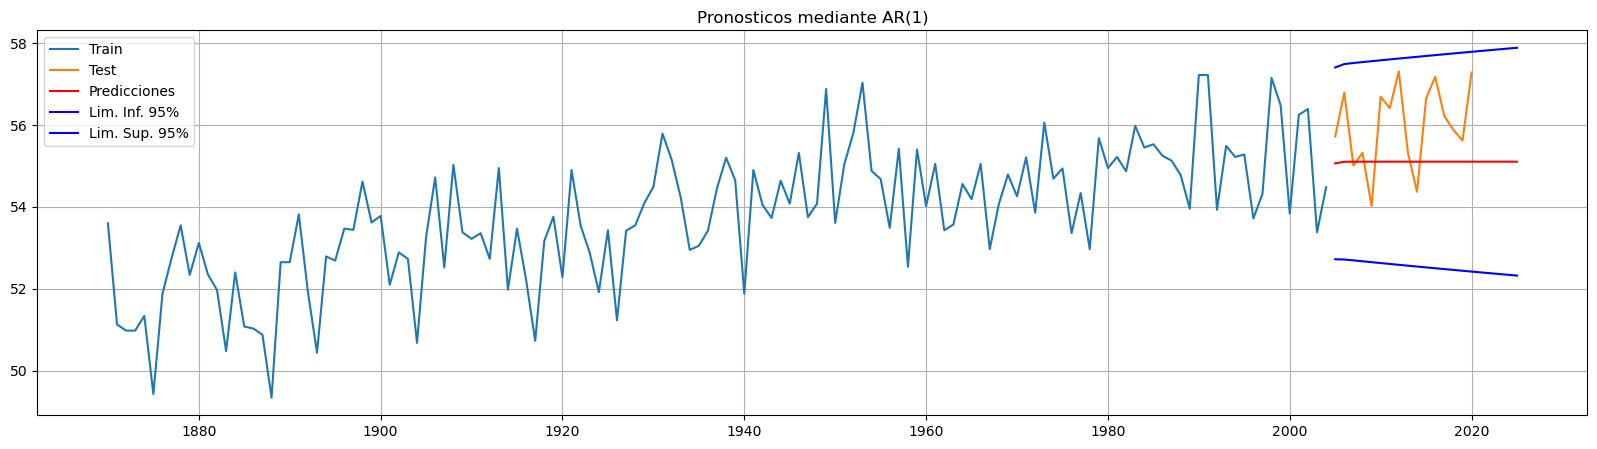

In [223]:
plt.figure(figsize=(20,5))
plt.grid()
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(result, label='Predicciones', color='red')
plt.plot(intervalos['lower Average'], label = 'Lim. Inf. 95%', color = 'blue')
plt.plot(intervalos['upper Average'], label = 'Lim. Sup. 95%', color = 'blue')
plt.legend(loc='best')
plt.title('Pronosticos mediante AR(1)')
plt.show()

In [224]:
predicciones = res.forecast(len(test))
predicciones = pd.DataFrame(predicciones)
predicciones = predicciones.reset_index()
predicciones

,index,predicted_mean
0,135,55.063945
1,136,55.102007
2,137,55.104488
3,138,55.104650
4,139,55.104660
5,140,55.104661
6,141,55.104661
7,142,55.104661
8,143,55.104661
9,144,55.104661


In [225]:
import numpy as np

acumulador1 = 0
acumulador2 = 0

for contador in range(0, len_test):
    acumulador1 = acumulador1 + (test.iloc[contador][0] - predicciones.iloc[contador][1])**2
    acumulador2 = acumulador2 + np.abs((test.iloc[contador][0] - predicciones.iloc[contador][1]) / test.iloc[contador][0])

mse = acumulador1 / len_test
rmse = np.round(np.sqrt(mse), 2)
mape = np.round((acumulador2 / len_test) * 100, 2)
print('RMSE = ', rmse, 'MAPE = ', mape, '%')

RMSE =  1.24 MAPE =  1.87 %
